In [1]:
import pandas as pd

deliveries = pd.read_csv('../data/Delivery.csv')
routes = pd.read_csv('../data/Routes.csv')

# Check data types
print(deliveries[['promised_days', 'actual_days']].dtypes)

# Make sure both columns are numeric
deliveries['promised_days'] = pd.to_numeric(deliveries['promised_days'], errors='raise')
deliveries['actual_days'] = pd.to_numeric(deliveries['actual_days'], errors='raise')

# Remove exact duplicate rows
deliveries = deliveries.drop_duplicates()

# Merge deliveries with routes using a LEFT JOIN
df = deliveries.merge(
    routes,
    on='route_id',
    how='left'
)

# Confirm exactly 12 rows
assert len(df) == 12, f"Expected 12 rows, but got {len(df)}"

# Confirm no route_id is unmatched
assert df['service_type'].isna().sum() == 0, \
    "Some route_id values were not matched with routes"

print("P1 checks passed.")
print(f"Number of rows: {len(df)}")
print("All route_id values matched successfully.")

promised_days    int64
actual_days      int64
dtype: object
P1 checks passed.
Number of rows: 12
All route_id values matched successfully.


In [2]:
df['delay_days'] = (
    df['actual_days'] - df['promised_days']
).clip(lower=0)

In [3]:
service_summary = (
    df.groupby('service_type')
      .agg(
          total_delay_days=('delay_days', 'sum'),
          delay_incidence_rate=(
              'actual_days',
              lambda x: (x > df.loc[x.index, 'promised_days']).mean() * 100
          )
      )
      .reset_index()
)

print(service_summary)

  service_type  total_delay_days  delay_incidence_rate
0      Express                12             66.666667
1     Standard                22             83.333333


In [4]:
route_delay = (
    df.groupby('route_id')['delay_days']
      .sum()
      .reset_index(name='total_delay_days')
)

top_route = route_delay.loc[route_delay['total_delay_days'].idxmax()]

overall_delay = df['delay_days'].sum()
top_route_share = (
    top_route['total_delay_days'] / overall_delay * 100
)

In [5]:
print(
    f"Route with greatest summed delay: "
    f"{top_route['route_id']}"
)

print(
    f"Greatest summed delay_days: "
    f"{top_route['total_delay_days']}"
)

print(
    f"Share of overall total delay_days: "
    f"{top_route_share:.2f}%"
)

Route with greatest summed delay: R4
Greatest summed delay_days: 14
Share of overall total delay_days: 41.18%


In [6]:
import matplotlib.pyplot as plt

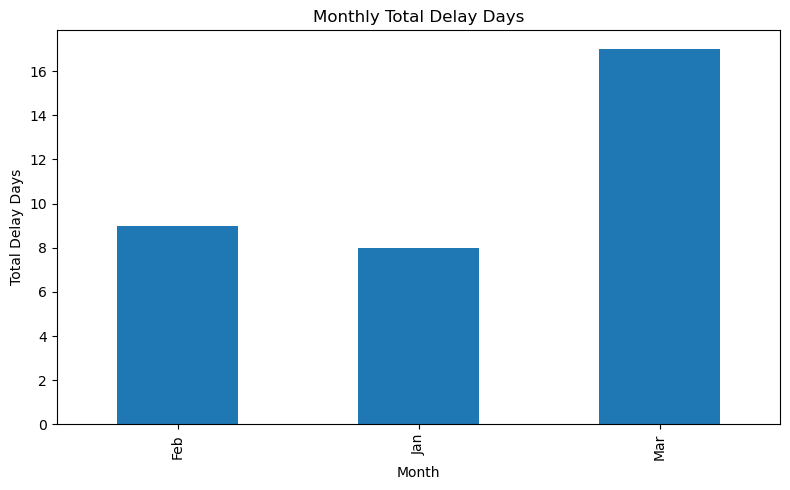

In [7]:
monthly_delay = (df.groupby('month')['delay_days'].sum())
plt.figure(figsize=(8, 5))

monthly_delay.plot(kind='bar')

plt.title('Monthly Total Delay Days')
plt.xlabel('Month')
plt.ylabel('Total Delay Days')

plt.tight_layout()


In [9]:
# Save chart
plt.savefig('../Output/python_chart.png', dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>